<a href="https://colab.research.google.com/github/sanchezmerinomiguelangel-sudo/Procesos-Estoc-sticos/blob/main/Copia_de_PAS_PRADO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio: simular y visualizar PAS

Objetivo final: completar un cuaderno como este para generar todas las imágenes del PAS de las diapositivas, subirlo a vuestro perfil de GitHub, y compartirlo conmigo. (Para final de la semana que viene, fecha a concretar).

Sobre el uso de IA generativa / LLMs:
* Se os anima a usarla para desatascaros en pasos pequeños y muy concretos (que te explique cómo hacer la media por filas de una matriz; que te explique cómo funciona cierta función que el profesor ha mencionado etc.).
* Pero no tiene sentido usarla para pasos excesivamente grandes en los que perdéis el control de qué se está haciendo (por ejemplo, decirle que te genere las figuras directamente).
* El verdadero objetivo final es entender el proceso, desarrollar habilidades de planificación, y asimilar las estructuras de pensamiento matemático-computacional subyacentes. Estáis en etapa formativa, no en etapa productiva.
* Como posible control, yo podré convocaros en clase o tutoría para que me expliquéis cómo funciona vuestro código.
* Pero, al fin y al cabo, lo que más está en juego es vuestra formación: adquirir valor añadido (ser capaz de desarrollar unas estructuras mentales que os permitan resolver problemas complejos en el futuro, problemas que quizás sean diferentes a los que hay hoy día), o ser una pieza de poco valor añadido y fácilmente sustituible (un “usuario de IA”).

Se recomienda que avancéis de aquí al lunes. Probablemente le dediquemos lunes y martes, y ya después pasemos a otra cosa. Y tendréis que entregarlo a final de semana (fecha a concretar).

Si escribís sobre este notebook que os comparto, vuestros cambios no se guardarán (porque solo tenéis permisos de lectura). Tendréis que crear una copia vuestra ("Archivo > Guardar una copia en Drive").

---------------------------------------------------------------

In [ ]:
import numpy as np
from matplotlib import pyplot as plt

## El núcleo: implementar una función para simular el PAS

Define una función `simular_PAS` que reciba tres argumentos:
* p: este es el parámetro principal del PAS. Es la probabilidad de tomar el valor 1 en cada paso (y la probabilidad de tomar el -1 sería $1-p$). Es un valor entre 0 y 1.
* n: el número de pasos a simular para cada trayectoria. Un número natural.
* reps: el número de trayectorias a simular. Un número natural.

La función debe devolver un array de numpy con dimensionalidad `(reps, n)`, que contenga los valores del PAS en cada paso para cada trayectoria.  

Esqueleto de la función a construir (a completar por vosotros):

In [ ]:
def simular_PAS(p,n,reps):
  # Input:
  # p: p es la probabilidad de tomar el valor 1, 1-p es la probabilidad de tomar el valor -1
  # n: n es el número de pasos del PAS
  # reps: es el número de trayectorias a simular

  Zn=np.random.choice([-1,1],(reps,n),p=[1-p,p])   #Se elige entre 1 y -1 con probabilidad p y 1-p

  Trayectorias=np.cumsum(Zn,axis=1)         #Se van sumando los valores de Zn, y se guardan en un array(reps,n)

  return Trayectorias

simular_PAS(0.5,10,2)

array([[-1, -2, -3, -2, -3, -2, -1,  0,  1,  2],
       [-1, -2, -1, -2, -1,  0,  1,  0, -1,  0]])

Primero piensa durante un rato cómo lo harías, e intenta completar la función. Si te quedas atrancado/a, puedes mirar la pista de abajo. **Importante**: lo fundamental de la frase anterior es "*si te quedas atrancado/a*", es decir, debes pensarlo un rato por tu cuenta. De lo contrario, si vas directo a la solución, no se produce ningún aprendizaje y no te sirve de nada.

----------------------------------------

## Visualización 1: diferentes trayectorias del PAS (sin media ni desviación típica teóricas)

Escribir código para crear las imágenes de las diapositivas 16 ($p=0.5$), 17 ($p=0.6$) y 18 ($p=0.4$) del tema 1.

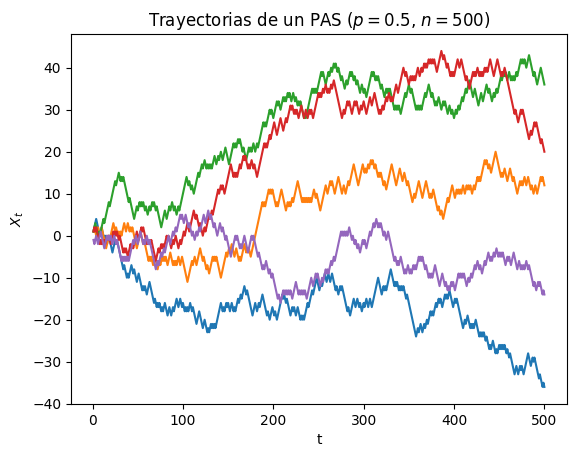

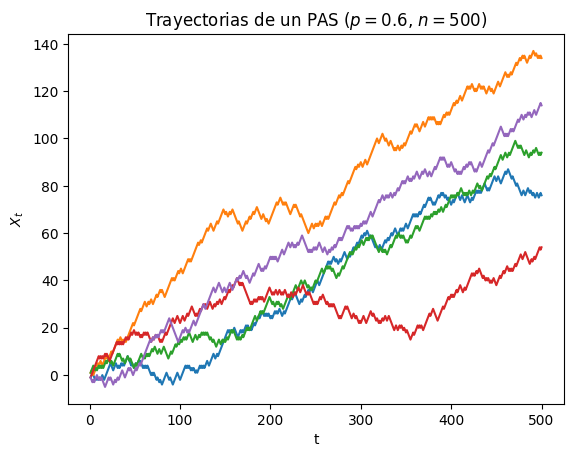

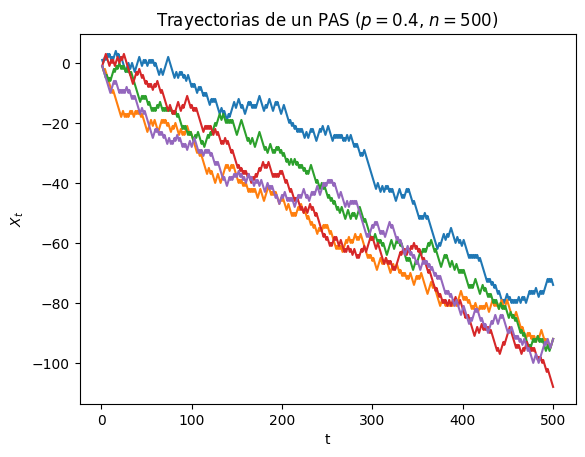

In [ ]:
# Creamos la imagen de la diapositiva 16

p1 = 0.5
n1 = 500
reps1 = 5

tiempo1 = np.arange(1, n1 + 1)   #Ponemos hasta n1 + 1 para incluir el 500

for i in range(reps1):
    plt.plot(tiempo1, simular_PAS(p1, n1, reps1)[i,:])      #Representamos los 5 PAS, recorriendo las 5 filas de simular_PAS con un for

plt.title(f'Trayectorias de un PAS ($p={p1}$, $n={n1}$)')
plt.xlabel('t')
plt.ylabel('$X_t$')

plt.show()




# Creamos la imagen de la diapositiva 17

p2 = 0.6
n2 = 500
reps2 = 5

tiempo2 = np.arange(1, n2 + 1)

for i in range(reps2):
    plt.plot(tiempo2, simular_PAS(p2, n2, reps2)[i,:])

plt.title(f'Trayectorias de un PAS ($p={p2}$, $n={n2}$)')
plt.xlabel('t')
plt.ylabel('$X_t$')

plt.show()






# Creamos la imagen de la diapositiva 18

p3 = 0.4
n3 = 500
reps3 = 5

tiempo3 = np.arange(1, n3 + 1)   #Ponemos hasta n1 + 1 para incluir el 500

for i in range(reps3):
    plt.plot(tiempo3, simular_PAS(p3, n3, reps3)[i,:])

plt.title(f'Trayectorias de un PAS ($p={p3}$, $n={n3}$)')
plt.xlabel('t')
plt.ylabel('$X_t$')

plt.show()


## Visualización 2: diferentes trayectorias del PAS (con media y desviación típica teóricas)

Escribir código para crear las imágenes de las diapositivas 30 ($p=0.5$), 31 ($p=0.75$), 32 ($p=0.95$) del tema 1.

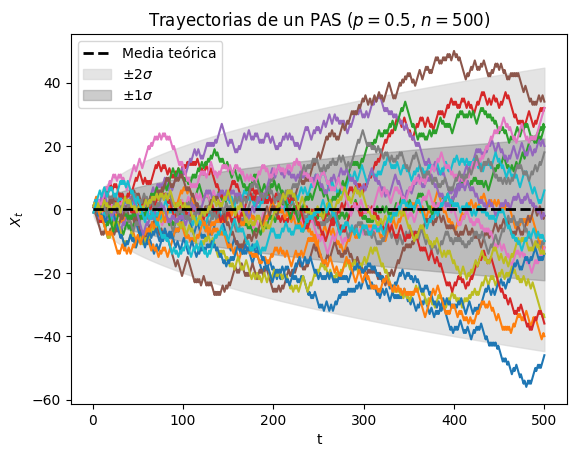

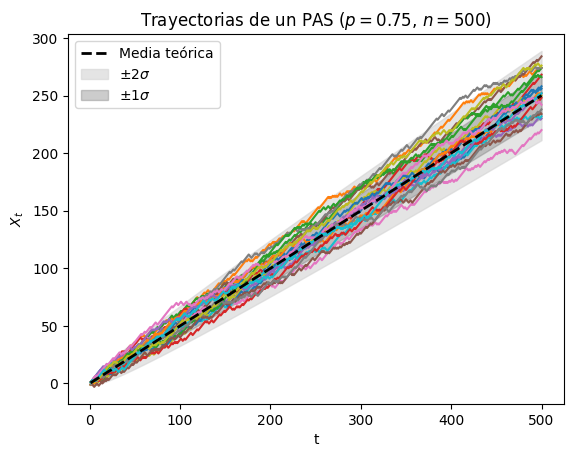

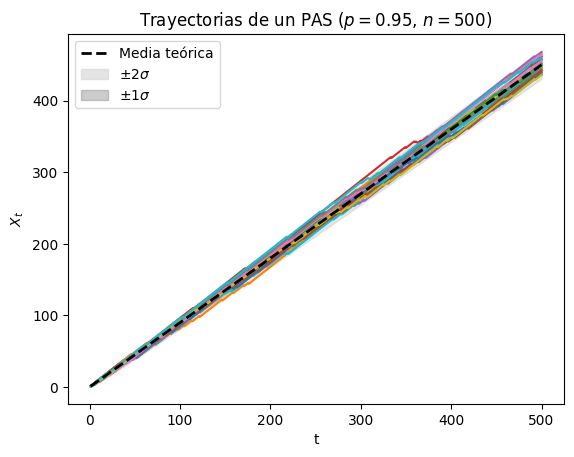

In [ ]:
# Creamos la imagen de la diapositiva 30

p4 = 0.5
n4 = 500
reps4 = 20


tiempo4 = np.arange(1, n4 + 1)

media1 = (2*p4-1)*tiempo4         #Creamos vector de medias (500 medias)

sigma1 = np.sqrt(4*p4*(1-p4)*tiempo4)    #Creamos el vector de desviaciones típicas (500 desv.tip)


for i in range(reps4):
    plt.plot(tiempo4, simular_PAS(p4, n4, reps4)[i,:])

plt.plot(tiempo4, media1, 'k--', linewidth=2, label='Media teórica')   #Representamos la media


plt.fill_between(tiempo4, media1 - 2*sigma1, media1 + 2*sigma1,
                 color='lightgray', alpha=0.6, label=r'$\pm 2\sigma$')    #Representamos la región que engloba 2*sigma1 respecto a la media

plt.fill_between(tiempo4, media1 - sigma1, media1 + sigma1,
                 color='gray', alpha=0.4, label=r'$\pm 1\sigma$')



plt.title(f'Trayectorias de un PAS ($p={p4}$, $n={n4}$)')
plt.xlabel('t')
plt.ylabel('$X_t$')
plt.legend(loc='upper left')

plt.show()






# Creamos la imagen de la diapositiva 31

p5 = 0.75
n5 = 500
reps5 = 20


tiempo5 = np.arange(1, n5 + 1)   #Ponemos hasta n1 + 1 para incluir el 500

media2 = (2*p5-1)*tiempo5

sigma2 = np.sqrt(4*p5*(1-p5)*tiempo5)


for i in range(reps5):
    plt.plot(tiempo5, simular_PAS(p5, n5, reps5)[i,:])

plt.plot(tiempo5, media2, 'k--', linewidth=2, label='Media teórica')


plt.fill_between(tiempo5, media2- 2*sigma2, media2 + 2*sigma2,
                 color='lightgray', alpha=0.6, label=r'$\pm 2\sigma$')

plt.fill_between(tiempo5, media2 - sigma2, media2 + sigma2,
                 color='gray', alpha=0.4, label=r'$\pm 1\sigma$')



plt.title(f'Trayectorias de un PAS ($p={p5}$, $n={n5}$)')
plt.xlabel('t')
plt.ylabel('$X_t$')
plt.legend(loc='upper left')

plt.show()






# Creamos la imagen de la diapositiva 32

p6 = 0.95
n6 = 500
reps6 = 20


tiempo6 = np.arange(1, n6 + 1)   #Ponemos hasta n1 + 1 para incluir el 500

media3 = (2*p6-1)*tiempo4

sigma3 = np.sqrt(4*p6*(1-p6)*tiempo6)


for i in range(reps6):
    plt.plot(tiempo6, simular_PAS(p6, n6, reps6)[i,:])

plt.plot(tiempo6, media3, 'k--', linewidth=2, label='Media teórica')


plt.fill_between(tiempo6, media3 - 2*sigma3, media3 + 2*sigma3,
                 color='lightgray', alpha=0.6, label=r'$\pm 2\sigma$')

plt.fill_between(tiempo6, media3 - sigma3, media3 + sigma3,
                 color='gray', alpha=0.4, label=r'$\pm 1\sigma$')



plt.title(f'Trayectorias de un PAS ($p={p6}$, $n={n6}$)')
plt.xlabel('t')
plt.ylabel('$X_t$')
plt.legend(loc='upper left')

plt.show()


## Visualización 3: visualización de la media empírica del PAS cuando aumentamos el número de trayectorias (junto con la media teórica)

Escribir código para crear la imagen de la diapositiva 35.

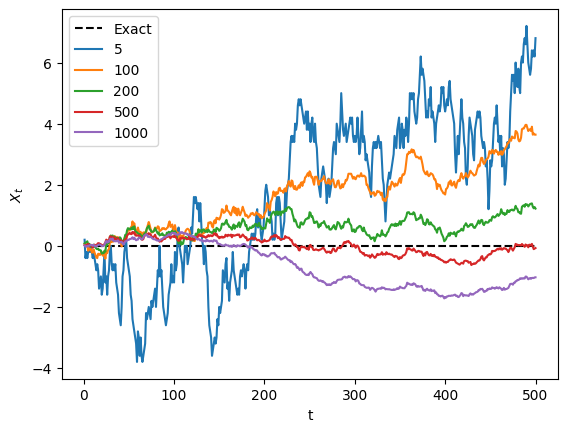

In [ ]:
# Creamos la imagen de la diapositiva 35

p7 = 0.5
n7= 500
reps7 = 1000


datos_pas = simular_PAS(p7, n7, reps7)    #Creamos todos los PAS, los 1000

tiempo7 = np.arange(1, n7 + 1)


plt.plot(tiempo7, (2*p7-1)*tiempo7, 'k--', label='Exact')     #Representamos la media teórica


cantidades = [5, 100, 200, 500, 1000]

for num in cantidades:
    media = np.mean(datos_pas[:num, :], axis=0)   #Hacemos la media empírica de datos_pas con i trayectorias
    plt.plot(tiempo7, media, label=num)

#Cuantas más trayectorias promediemos, mejor nos aproximaremos a la media teórica

plt.xlabel('t')
plt.ylabel('$X_t$')
plt.legend(loc='upper left')


plt.show()
